In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from c50py import C5Classifier

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from econml.dml import CausalForestDML

import seaborn as sns

In [2]:
data = pd.read_csv('cdc_brfss.csv')
print(data.shape)
data.head()

(253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# Drop NaN value
print("Any null value:", any(data.isnull()))
print("Any NaN value:", any(data.isna()))
print("Before Droping NaN Number of Rows:", len(data))

data = data.dropna()
data = data.drop_duplicates()
print("After Droping NaN Number of Rows and Duplicates:", len(data))

# Move 'Diabetes_binary' column to the end of dataframe
data['Diabetes_binary'] = data.pop('Diabetes_binary')

data.tail()

Any null value: True
Any NaN value: True
Before Droping NaN Number of Rows: 253680
After Droping NaN Number of Rows and Duplicates: 229474


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
253675,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0,0.0
253676,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0,1.0
253677,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0,0.0
253678,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0,0.0
253679,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0,1.0


Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64


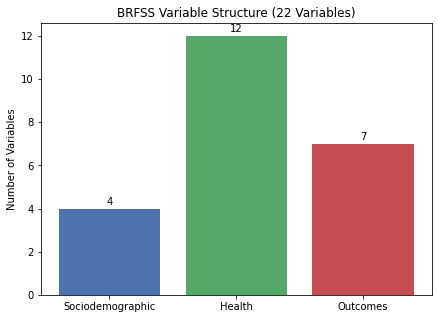

In [4]:
cdc_corr = data.corr()
print(cdc_corr.iloc[-1,:].sort_values(ascending=False))

groups = {
    "Sociodemographic": [
        "Sex", "Age", "Education", "Income"
    ],
    "Health": [
        "Smoker", "PhysActivity", "Fruits", "Veggies", "HealthyDiet",
        "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost",
        "CholCheck", "BMI", "HighBP", "HighChol"
    ],
    "Outcomes": [
        "Diabetes_binary", "GenHlth", "DiffWalk",
        "HeartDiseaseorAttack", "Stroke",
        "PhysHlth", "MentHlth"
    ]
}

counts = {k: len(v) for k, v in groups.items()}

plt.figure(figsize=(7,5))
bars = plt.bar(
    counts.keys(),
    counts.values(),
    color=["#4C72B0", "#55A868", "#C44E52"]
)

plt.title("BRFSS Variable Structure (22 Variables)")
plt.ylabel("Number of Variables")

# optional labels inside bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval),
             ha='center', va='bottom')

plt.show()

In [5]:
#split
def data_split(data):
    
    X = data.iloc[:,:-1]
    y = data.iloc[:,-1]
    
    train_x, temp_x, train_y, temp_y = train_test_split(X,y,test_size = 0.3, random_state=0)

    test_x, val_x, test_y, val_y = train_test_split(temp_x, temp_y, test_size=0.3333, random_state=0, stratify=temp_y)


# Check sizes
    print("Train size:", len(train_x))
    print("Test size:", len(test_x))
    print("Validation size:", len(val_x))
    
    return train_x, test_x, train_y, test_y, val_x, val_y

train_x, test_x, train_y, test_y, val_x, val_y = data_split(data)

Train size: 160631
Test size: 45897
Validation size: 22946


In [5]:

train_df = pd.concat([train_x, train_y], axis=1)
test_df  = pd.concat([test_x, test_y], axis=1)
val_df   = pd.concat([val_x, val_y], axis=1)

train_df.to_csv("cdc_train.csv", index=False)
test_df.to_csv("cdc_test.csv", index=False)
val_df.to_csv("cdc_validation.csv", index=False)


In [4]:
class FeatureSelectorDF(BaseEstimator, TransformerMixin):
    def __init__(self, score_func=f_classif, k=20):
        self.score_func = score_func
        self.k = k
    
    def fit(self, X, y=None):
        self.selector = SelectKBest(score_func=self.score_func, k=self.k)
        self.selector.fit(X, y)
        self.columns_ = X.columns[self.selector.get_support()]
        return self
    
    def transform(self, X):
        X_selected = self.selector.transform(X)
        return pd.DataFrame(X_selected, columns=self.columns_, index=X.index)

/storage/home/tvw5517/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [07:47:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/home/tvw5517/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [07:47:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/home/tvw5517/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [07:47:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/home/tvw5517/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [07:47:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

[LightGBM] [Info] Number of positive: 19641, number of negative: 108863
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 199
[LightGBM] [Info] Number of data points in the train set: 128504, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.152843 -> initscore=-1.712471
[LightGBM] [Info] Start training from score -1.712471
[LightGBM] [Info] Number of positive: 19642, number of negative: 108863
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006944 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 199
[LightGBM] [Info] Number of data points in the train set: 128505, number of used features: 20
[LightGBM] [Info

/storage/home/tvw5517/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/storage/home/tvw5517/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/storage/home/tvw5517/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/storage/home/tvw55

                      Accuracy  Precision    Recall       AUC
Model                                                        
Extra Trees           0.835094   0.407899  0.174446  0.750462
Decision Tree         0.774141   0.288146  0.324739  0.589802
Random Forest         0.844339   0.473958  0.167318  0.776240
KNN                   0.831471   0.392914  0.188050  0.693971
AdaBoost              0.851504   0.545963  0.170454  0.805071
HistGradientBoosting  0.853372   0.575758  0.154570  0.813709
XGBoost               0.851728   0.548147  0.170862  0.808460
LightGBM              0.853851   0.580465  0.158113  0.813890
CatBoost              0.852276   0.555183  0.168459  0.811607
C5.0                  0.847147   0.000000  0.000000  0.499996


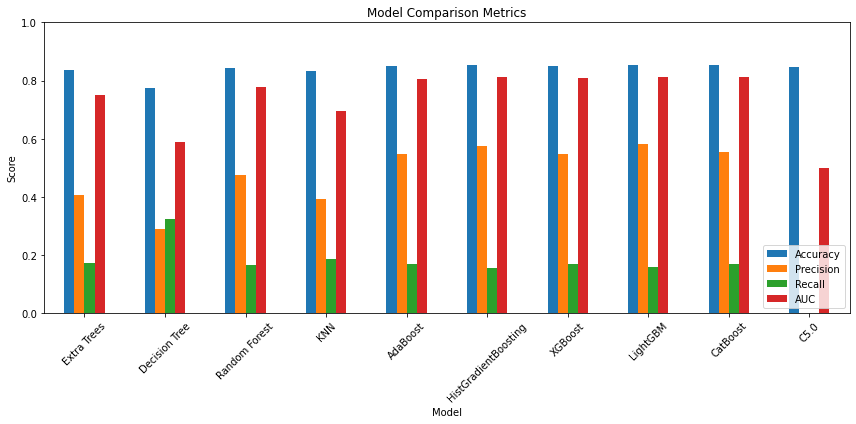

In [5]:
# with c5
# Assuming FeatureSelectorDF is the feature selection class

models = {
    "Extra Trees": ExtraTreesClassifier(random_state=0),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(random_state=0),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

results = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for name, model in models.items():
    acc_list, prec_list, rec_list, auc_list = [], [], [], []
    
    pipeline = Pipeline([
        ('feature_selection', FeatureSelectorDF(k=20)),
        ('model', model)
    ])
    
    for train_idx, val_idx in skf.split(train_x, train_y):
        X_train, X_val = train_x.iloc[train_idx], train_x.iloc[val_idx]
        y_train, y_val = train_y.iloc[train_idx], train_y.iloc[val_idx]
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        y_prob = pipeline.predict_proba(X_val)[:,1] if hasattr(pipeline, "predict_proba") else y_pred
        
        acc_list.append(accuracy_score(y_val, y_pred))
        prec_list.append(precision_score(y_val, y_pred))
        rec_list.append(recall_score(y_val, y_pred))
        auc_list.append(roc_auc_score(y_val, y_prob))
        
    results.append({
        'Model': name,
        'Accuracy': np.mean(acc_list),
        'Precision': np.mean(prec_list),
        'Recall': np.mean(rec_list),
        'AUC': np.mean(auc_list)
    })

#Run C5.0 separately
from c50py import C5Classifier

acc_list, prec_list, rec_list, auc_list = [], [], [], []

for train_idx, val_idx in skf.split(train_x, train_y):
    X_train, X_val = train_x.iloc[train_idx], train_x.iloc[val_idx]
    y_train, y_val = train_y.iloc[train_idx], train_y.iloc[val_idx]
    
    model = C5Classifier()
    model.feature_names = list(X_train.columns)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]
    
    acc_list.append(accuracy_score(y_val, y_pred))
    prec_list.append(precision_score(y_val, y_pred))
    rec_list.append(recall_score(y_val, y_pred))
    auc_list.append(roc_auc_score(y_val, y_prob))

results.append({
    'Model': "C5.0",
    'Accuracy': np.mean(acc_list),
    'Precision': np.mean(prec_list),
    'Recall': np.mean(rec_list),
    'AUC': np.mean(auc_list)
})

#Convert to DataFrame
df_results = pd.DataFrame(results)
df_results = df_results.set_index('Model')
print(df_results)

#Plotting
df_results.plot(kind='bar', figsize=(12,6))
plt.title("Model Comparison Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# testing a novel approach (causal forest) treatment combo

def data_split(data):
    X = data.iloc[:,:-1]
    y = data.iloc[:,-1]
    
    train_x, temp_x, train_y, temp_y = train_test_split(
        X, y, test_size=0.3, random_state=0
    )

    test_x, val_x, test_y, val_y = train_test_split(
        temp_x, temp_y, test_size=0.3333, random_state=0, stratify=temp_y
    )

    print("Train size:", len(train_x))
    print("Test size:", len(test_x))
    print("Validation size:", len(val_x))
    
    return train_x, test_x, train_y, test_y, val_x, val_y

train_x, test_x, train_y, test_y, val_x, val_y = data_split(data)

if "BMI_binary" not in train_x.columns:
    train_x["BMI_binary"] = (train_x["BMI"] >= 30).astype(int)
    test_x["BMI_binary"] = (test_x["BMI"] >= 30).astype(int)
    val_x["BMI_binary"] = (val_x["BMI"] >= 30).astype(int)

treatment_cols = ["PhysActivity", "BMI_binary", "Smoker"]

T_train = train_x[treatment_cols].values
T_test  = test_x[treatment_cols].values
T_val   = val_x[treatment_cols].values

X_train = train_x.drop(columns=treatment_cols)
X_test  = test_x.drop(columns=treatment_cols)
X_val   = val_x.drop(columns=treatment_cols)

Y_train = train_y.values
Y_test  = test_y.values
Y_val   = val_y.values

model_y = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=0
)

model_t = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=0
)

causal_model = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=300,
    min_samples_leaf=20,
    max_depth=10,
    random_state=0
)

causal_model.fit(Y_train, T_train, X=X_train)

n = len(X_test)

T_unhealthy = np.array([[0, 1, 1]] * n)
T_exercise  = np.array([[1, 1, 1]] * n)
T_weight    = np.array([[0, 0, 1]] * n)
T_smoking   = np.array([[0, 1, 0]] * n)
T_two       = np.array([[1, 0, 1]] * n)
T_all       = np.array([[1, 0, 0]] * n)

effect_exercise = causal_model.effect(X_test, T0=T_unhealthy, T1=T_exercise)
effect_weight   = causal_model.effect(X_test, T0=T_unhealthy, T1=T_weight)
effect_smoking  = causal_model.effect(X_test, T0=T_unhealthy, T1=T_smoking)
effect_two      = causal_model.effect(X_test, T0=T_unhealthy, T1=T_two)
effect_all      = causal_model.effect(X_test, T0=T_unhealthy, T1=T_all)

def find_best_intervention(i):
    effects = {
        "Exercise only": effect_exercise[i],
        "Weight loss only": effect_weight[i],
        "Quit smoking": effect_smoking[i],
        "Exercise + weight loss": effect_two[i],
        "All three": effect_all[i]
    }
    
    best = min(effects, key=effects.get)
    return best, effects[best]

results = [find_best_intervention(i) for i in range(len(X_test))]

for i in range(10):
    print(f"\nPerson {i}")
    print(f"Best intervention: {results[i][0]}")
    print(f"Estimated risk reduction: {abs(results[i][1]):.4f}")

best_choices = [r[0] for r in results]
print("\nIntervention distribution:")
print(pd.Series(best_choices).value_counts())

print("\nAverage effects:")
print("Exercise:", effect_exercise.mean())
print("Weight loss:", effect_weight.mean())
print("Quit smoking:", effect_smoking.mean())
print("Exercise + weight:", effect_two.mean())
print("All three:", effect_all.mean())

val_effect = causal_model.effect(
    X_val,
    T0=np.array([[0,1,1]] * len(X_val)),
    T1=np.array([[1,0,0]] * len(X_val))
)

print("\nValidation effect (all interventions):", val_effect.mean())

Train size: 160631
Test size: 45897
Validation size: 22946

Person 0
Best intervention: Weight loss only
Estimated risk reduction: 0.0000

Person 1
Best intervention: Weight loss only
Estimated risk reduction: 0.0000

Person 2
Best intervention: Weight loss only
Estimated risk reduction: 0.0000

Person 3
Best intervention: Weight loss only
Estimated risk reduction: 0.0000

Person 4
Best intervention: Weight loss only
Estimated risk reduction: 0.0000

Person 5
Best intervention: All three
Estimated risk reduction: 0.0050

Person 6
Best intervention: Weight loss only
Estimated risk reduction: 0.0000

Person 7
Best intervention: Weight loss only
Estimated risk reduction: 0.0000

Person 8
Best intervention: Weight loss only
Estimated risk reduction: 0.0000

Person 9
Best intervention: Weight loss only
Estimated risk reduction: 0.0000

Intervention distribution:
Weight loss only          24586
Exercise only              7091
Exercise + weight loss     5049
Quit smoking               4963
Al

In [3]:
#corrected causal for only exercise

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML


# 1. Train / Test / Val Split

def data_split(data):
    X = data.iloc[:, :-1]
    y = data.iloc[:, -1]

    train_x, temp_x, train_y, temp_y = train_test_split(
        X, y, test_size=0.3, random_state=0, stratify=y
    )

    test_x, val_x, test_y, val_y = train_test_split(
        temp_x, temp_y, test_size=0.3333, random_state=0, stratify=temp_y
    )

    return train_x, test_x, train_y, test_y, val_x, val_y


train_x, test_x, train_y, test_y, val_x, val_y = data_split(data)


# 2. Define Treatment (Exercise)

T_train = train_x["PhysActivity"].values
T_test  = test_x["PhysActivity"].values
T_val   = val_x["PhysActivity"].values


# 3. Remove leakage variables

# VERY IMPORTANT: remove variables closely tied to treatment
leakage_cols = [
    "PhysActivity",
    "BMI",
    "GenHlth",
    "PhysHlth",
    "DiffWalk",
    "HeartDiseaseorAttack",
    "Stroke"
]

X_train = train_x.drop(columns=leakage_cols, errors="ignore")
X_test  = test_x.drop(columns=leakage_cols, errors="ignore")
X_val   = val_x.drop(columns=leakage_cols, errors="ignore")

Y_train = train_y.values
Y_test  = test_y.values
Y_val   = val_y.values


# 4. Models

model_y = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=0,
    n_jobs=-1
)

model_t = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=0,
    n_jobs=-1
)


# 5. Causal Forest
causal_model = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=500,
    min_samples_leaf=50,
    max_depth=15,
    random_state=0,
    discrete_treatment=True
)

causal_model.fit(Y_train, T_train, X=X_train)


# 6. Treatment Effect

effect_test = causal_model.effect(X_test)
effect_val  = causal_model.effect(X_val)

print("\nAverage Treatment Effect (Test):", effect_test.mean())
print("Average Treatment Effect (Validation):", effect_val.mean())


# 7. Inspect Distribution

print("\nEffect Summary:")
print(pd.Series(effect_test).describe())


# 8. Simple Policy Rule

# Recommend exercise if effect < 0 (reduces diabetes risk)
recommend = (effect_test < 0).astype(int)

print("\nRecommended Exercise Rate:", recommend.mean())

# 9. Optional: Top Individuals

top_idx = np.argsort(effect_test)[:10]

for i in top_idx:
    print(f"\nPerson {i}")
    print(f"Estimated risk reduction: {abs(effect_test[i]):.4f}")


Average Treatment Effect (Test): -0.03514069490896422
Average Treatment Effect (Validation): -0.03527017354702373

Effect Summary:
count    45897.000000
mean        -0.035141
std          0.031839
min         -0.151116
25%         -0.056281
50%         -0.031246
75%         -0.008592
max          0.046269
dtype: float64

Recommended Exercise Rate: 0.8821055842429788

Person 35468
Estimated risk reduction: 0.1511

Person 26127
Estimated risk reduction: 0.1502

Person 33197
Estimated risk reduction: 0.1469

Person 9209
Estimated risk reduction: 0.1445

Person 17784
Estimated risk reduction: 0.1445

Person 6527
Estimated risk reduction: 0.1438

Person 29143
Estimated risk reduction: 0.1438

Person 40173
Estimated risk reduction: 0.1438

Person 17605
Estimated risk reduction: 0.1431

Person 21416
Estimated risk reduction: 0.1431


In [9]:
# Fruits and Veggies
train_x["HealthyDiet"] = (
    (train_x["Fruits"] > 0) & (train_x["Veggies"] > 0)
).astype(int)

data["Diabetes_binary"] = data.pop("Diabetes_binary")
train_x, test_x, train_y, test_y, val_x, val_y = data_split(data)

T_train_diet = train_x["HealthyDiet"].values
T_test_diet  = test_x["HealthyDiet"].values
T_val_diet   = val_x["HealthyDiet"].values

diet_leakage = [
    "HealthyDiet",
    "Fruits",
    "Veggies"
]

X_train_diet = train_x.drop(columns=leakage_cols + diet_leakage, errors="ignore")
X_test_diet  = test_x.drop(columns=leakage_cols + diet_leakage, errors="ignore")
X_val_diet   = val_x.drop(columns=leakage_cols + diet_leakage, errors="ignore")

causal_model_diet = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=500,
    min_samples_leaf=50,
    max_depth=15,
    random_state=0,
    discrete_treatment=True
)

causal_model_diet.fit(Y_train, T_train_diet, X=X_train_diet)

effect_test_diet = causal_model_diet.effect(X_test_diet)

print("\nDiet ATE (Test):", effect_test_diet.mean())
print(pd.Series(effect_test_diet).describe())

# 7. Inspect Distribution

print("\nEffect Summary:")
print(pd.Series(effect_test).describe())

top_idx = np.argsort(effect_test)[:10]

for i in top_idx:
    print(f"\nPerson {i}")
    print(f"Estimated risk reduction: {abs(effect_test[i]):.4f}")


Diet ATE (Test): -0.01192921936312643
count    45897.000000
mean        -0.011929
std          0.020288
min         -0.112817
25%         -0.023155
50%         -0.009776
75%          0.000160
max          0.115167
dtype: float64

Effect Summary:
count    45897.000000
mean        -0.035141
std          0.031839
min         -0.151116
25%         -0.056281
50%         -0.031246
75%         -0.008592
max          0.046269
dtype: float64

Recommended Exercise Rate: 0.8821055842429788

Person 35468
Estimated risk reduction: 0.1511

Person 26127
Estimated risk reduction: 0.1502

Person 33197
Estimated risk reduction: 0.1469

Person 9209
Estimated risk reduction: 0.1445

Person 17784
Estimated risk reduction: 0.1445

Person 6527
Estimated risk reduction: 0.1438

Person 29143
Estimated risk reduction: 0.1438

Person 40173
Estimated risk reduction: 0.1438

Person 17605
Estimated risk reduction: 0.1431

Person 21416
Estimated risk reduction: 0.1431


Train size: 160631
Test size: 45897
Validation size: 22946
Exercise ATE: -0.03334185948653265
Diet ATE: -0.009952764908017804
count    45897.000000
mean        -0.033342
std          0.029585
min         -0.144907
25%         -0.053909
50%         -0.029838
75%         -0.008644
max          0.042486
dtype: float64
count    45897.000000
mean        -0.009953
std          0.020527
min         -0.095773
25%         -0.020952
50%         -0.008238
75%          0.001329
max          0.110121
dtype: float64


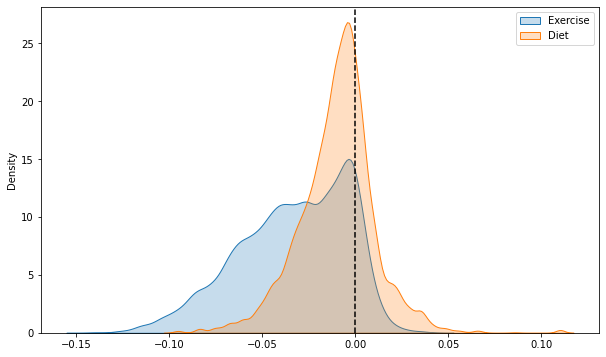

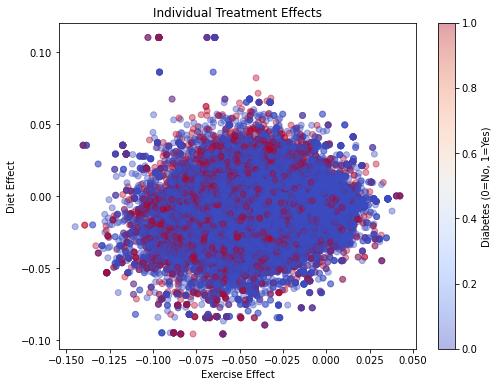

Exercise recommendation rate: 0.8829117371505762
Diet recommendation rate: 0.7188269385798636
Combined recommendation rate: 0.963134845414733


In [6]:
# Feature engineering (before split)

data["HealthyDiet"] = (
    (data["Fruits"] > 0) & (data["Veggies"] > 0)
).astype(int)

data["Diabetes_binary"] = data.pop("Diabetes_binary")

train_x, test_x, train_y, test_y, val_x, val_y = data_split(data)


T_train_ex = train_x["PhysActivity"].values
T_test_ex  = test_x["PhysActivity"].values
T_val_ex   = val_x["PhysActivity"].values

T_train_diet = train_x["HealthyDiet"].values
T_test_diet  = test_x["HealthyDiet"].values
T_val_diet   = val_x["HealthyDiet"].values


leakage_cols = [
    "PhysActivity",
    "BMI",
    "GenHlth",
    "PhysHlth",
    "DiffWalk",
    "HeartDiseaseorAttack",
    "Stroke"
]

diet_leakage = [
    "HealthyDiet",
    "Fruits",
    "Veggies"
]


X_train_ex = train_x.drop(columns=leakage_cols, errors="ignore")
X_test_ex  = test_x.drop(columns=leakage_cols, errors="ignore")
X_val_ex   = val_x.drop(columns=leakage_cols, errors="ignore")

X_train_diet = train_x.drop(columns=leakage_cols + diet_leakage, errors="ignore")
X_test_diet  = test_x.drop(columns=leakage_cols + diet_leakage, errors="ignore")
X_val_diet   = val_x.drop(columns=leakage_cols + diet_leakage, errors="ignore")


Y_train = train_y.values
Y_test  = test_y.values
Y_val   = val_y.values


model_y = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=0,
    n_jobs=-1
)

model_t = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=0,
    n_jobs=-1
)


cf_ex = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=500,
    min_samples_leaf=50,
    max_depth=15,
    random_state=0,
    discrete_treatment=True
)

cf_ex.fit(Y_train, T_train_ex, X=X_train_ex)

effect_test_ex = cf_ex.effect(X_test_ex)
effect_val_ex  = cf_ex.effect(X_val_ex)


cf_diet = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=500,
    min_samples_leaf=50,
    max_depth=15,
    random_state=0,
    discrete_treatment=True
)

cf_diet.fit(Y_train, T_train_diet, X=X_train_diet)

effect_test_diet = cf_diet.effect(X_test_diet)
effect_val_diet  = cf_diet.effect(X_val_diet)


print("Exercise ATE:", effect_test_ex.mean())
print("Diet ATE:", effect_test_diet.mean())

print(pd.Series(effect_test_ex).describe())
print(pd.Series(effect_test_diet).describe())


plt.figure(figsize=(10,6))
sns.kdeplot(effect_test_ex, label="Exercise", fill=True)
sns.kdeplot(effect_test_diet, label="Diet", fill=True)
plt.axvline(0, linestyle='--', color='black')
plt.legend()
plt.show()


plt.figure(figsize=(8,6))

plt.scatter(
    effect_test_ex,
    effect_test_diet,
    c = Y_test,
    cmap = "coolwarm",
    alpha=0.4
)

plt.colorbar(label="Diabetes (0=No, 1=Yes)")
plt.xlabel("Exercise Effect")
plt.ylabel("Diet Effect")
plt.title("Individual Treatment Effects")

plt.show()


recommend_ex = (effect_test_ex < 0)
recommend_diet = (effect_test_diet < 0)
combined_policy = recommend_ex | recommend_diet

print("Exercise recommendation rate:", recommend_ex.mean())
print("Diet recommendation rate:", recommend_diet.mean())
print("Combined recommendation rate:", combined_policy.mean())

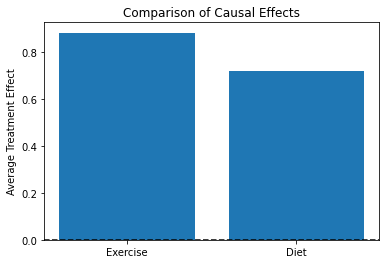

In [8]:
means = [
    recommend_ex.mean(),
    recommend_diet.mean()
]

labels = ["Exercise", "Diet"]

plt.figure(figsize=(6,4))
plt.bar(labels, means)

plt.axhline(0, color="black", linestyle="--")

plt.ylabel("Average Treatment Effect")
plt.title("Comparison of Causal Effects")

plt.show()